In [1]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

# 1. 모델 초기화
model = init_chat_model(
    "google_genai:gemini-2.5-flash",
    temperature=0
)

In [5]:
from typing import TypedDict, Annotated
from langchain_core.messages import AnyMessage, HumanMessage
from langgraph.graph import StateGraph, START, END, add_messages

# 2. State 정의 (정석!)
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [6]:
# 3. Node 정의
def greet(state: State):
    response = model.invoke(
        state["messages"]
    )
    return {"messages": [response]}

def goodbye(state: State):

    human_message = HumanMessage(content="안녕! 잘 가!")
    response = model.invoke(
        state["messages"] + [human_message]
    )
    return {"messages": [human_message, response]}


In [7]:
# 4. Graph 생성
graph_builder = StateGraph(State)

# 5. Graph에 Node 추가
graph_builder.add_node("greet_node", greet)
graph_builder.add_node("goodbye_node", goodbye)

# 6. Edge 추가하여 Node 연결
graph_builder.add_edge(START, "greet_node")
graph_builder.add_edge("greet_node", "goodbye_node")
graph_builder.add_edge("goodbye_node", END)

# 7. Graph를 실행 가능한 형태로 컴파일
graph = graph_builder.compile()

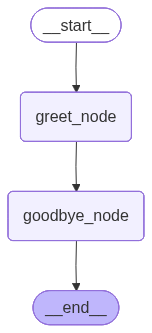

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
# 8. Graph 실행
initial_state: State = {
    "messages": [HumanMessage(content="안녕! 난 김일남이야!")],
}

result = graph.invoke(initial_state)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [9]:
for msg in result["messages"]:
    print(f"[{type(msg).__name__}] {msg.content}")

[HumanMessage] 안녕! 난 김일남이야!
[AIMessage] 안녕, 김일남 씨! 만나서 반가워요. 😊

무엇을 도와드릴까요?
[HumanMessage] 안녕! 잘 가!
[AIMessage] 안녕히 가세요! 다음에 또 만나요! 😊
